# Sobre o Notebook

Este notebook gera conversas simulando interações em redes sociais utilizando o **Network Simulator**, um *framework* de código aberto baseado em Grandes Modelos de Linguagem (LLMs), desenvolvido por Jeon et al. e descrito no artigo:

> **Simulating conversations on social media with generative agent-based models**  
> https://doi.org/10.1140/epjds/s13688-025-00593-3

O notebook também calcula as métricas implementadas por meio da biblioteca NELA (News Landscape) e as características estruturais das conversas.

Sua implementação foi desenvolvida a partir do notebook de exemplo disponibilizado pelos autores para reprodução dos experimentos:

https://github.com/minsoos/network_simulator/blob/master/example/example.ipynb

Repositório oficial do projeto dos autores: https://github.com/minsoos/network_simulator/

---

## Exportação dos Resultados

O notebook inclui células para gerar e exportar arquivos, que incluem:

- a conversa simulada;
- as métricas calculadas.

Os arquivos são salvos em formato **CSV** e baixados automaticamente para o computador.

Caso não deseje realizar o download automático, remova ou comente as linhas que contêm `files.download`, identificadas pelo comentário:

```python
# Download csv
```

---

## Requisitos

Antes de executar o notebook, configure as seguintes variáveis:

- **`API_KEY`**: sua chave de acesso à API do GitHub;
- **`NEWS`**: título ou mensagem inicial que dará origem à conversa simulada;
- **`NEWS_BODY`**: texto complementar da notícia (incluindo informações de *fact-checking* para contextualizar os agentes);
- **`CSV`**: identificador utilizado para nomear os arquivos gerados. Recomenda-se o formato `true_x` ou `false_x`, onde:
  - `x` é um identificador numérico da conversa;
  - `true` e `false` indicam se a notícia utilizada como entrada corresponde, respectivamente, a um conteúdo verdadeiro ou falso.

As demais variáveis possuem valores padrão e sua modificação é opcional.

# Configuração do Ambiente

Instale as seguintes bibliotecas

In [ ]:
!sudo apt install libenchant-2-2
!pip install network-simulator
!pip install openai
!pip install nela_features

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  aspell aspell-en dictionaries-common enchant-2 hunspell-en-us libaspell15
  libhunspell-1.7-0 libtext-iconv-perl
Suggested packages:
  aspell-doc spellutils wordlist hunspell openoffice.org-hunspell
  | openoffice.org-core libenchant-2-voikko
The following NEW packages will be installed:
  aspell aspell-en dictionaries-common enchant-2 hunspell-en-us libaspell15
  libenchant-2-2 libhunspell-1.7-0 libtext-iconv-perl
0 upgraded, 9 newly installed, 0 to remove and 3 not upgraded.
Need to get 1,431 kB of archives.
After this operation, 5,501 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libtext-iconv-perl amd64 1.7-7build3 [14.3 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libaspell15 amd64 0.60.8-4build1 [325 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 dicti

In [ ]:
import sys
import importlib

print(f"Python: {sys.version}")

packages = {
    "anytree": "Anytree",
    "soil": "Soil",
    "scipy": "Scipy",
    "numpy": "Numpy",
    "enchant": "Pyenchant"
}

# View versions
for module, name in packages.items():
    try:
        mod = importlib.import_module(module)
        version = getattr(mod, "__version__", "Versão não disponível")
        print(f"{name}: {version}")
    except ImportError:
        print(f"{name}: NÃO INSTALADO")

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
Anytree: 2.12.1
Soil: 0.20.7
Scipy: 1.16.3
Numpy: 2.0.2
Pyenchant: 3.3.0


Clone o repositório do GitHub associado ao simulador

In [ ]:
!git clone https://github.com/minsoos/network_simulator.git

Cloning into 'network_simulator'...
remote: Enumerating objects: 399, done.
remote: Counting objects: 100% (166/166), done.
remote: Compressing objects: 100% (108/108), done.
remote: Total 399 (delta 88), reused 82 (delta 51), pack-reused 233 (from 1)
Receiving objects: 100% (399/399), 885.64 KiB | 4.64 MiB/s, done.
Resolving deltas: 100% (196/196), done.


Importe as bibliotecas

In [ ]:
import subprocess
import os
import time

from network_simulator import make_yml, make_network_agents_yml
from network_simulator import get_pivoted_data, get_type_agents
from network_simulator import POST_TEMPLATE, REPLY_TEMPLATE, INSTRUCTIONS_TEMPLATE
from network_simulator import transform_time
from network_simulator import correctness_prompt, correctness_percentage
from anytree import Node, RenderTree, LevelOrderIter
from anytree.iterators import LevelOrderGroupIter, PreOrderIter
from network_simulator import Post
from network_simulator.gpt3_5 import send_prompt_openai

import openai

In [ ]:
from nela_features.nela_features import NELAFeatureExtractor
import nltk

resources = [
    'punkt',
    'punkt_tab',
    'averaged_perceptron_tagger',
    'averaged_perceptron_tagger_eng',
    'wordnet',
    'omw-1.4'
]

for r in resources:
    nltk.download(r)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


# Definindo os parâmetros para a simulação.

*   Parâmetros globais (network e motor de simulação)
*   Parâmetros de simulação
*   Parâmetros de agentes

In [ ]:
folder = os.path.join('network_simulator/schema')
name_simulation = 'simulation_tutorial'

# Agents parameters
network_agents_parameters = {
    "default": {
        "id_message": "NaN",
        "has_tv": "false",
        "cause": -1,
        "method": "NaN",
        "type": "dumb",
        "response": "NaN",
        "stance": "agree",
        "repost": "NaN",
        "parent_id": "NaN"

    },

    "DumbViewer": [
        {"weight": 1, "type": "dumb"},
        {"weight": 1, "type": "dumb", "has_tv": "true"}
    ],
    "HerdViewer": [
        {"weight": 1, "type": "herd", "stance": "neutral"},
        {"weight": 1, "type": "herd", "stance": "neutral"}
    ],
    "WiseViewer": [
        {"weight": 1, "type": "wise", "stance": "against"},
        {"weight": 1, "type": "wise", "stance": "neutral"},
        {"weight": 1, "type": "wise", "stance": "neutral"},
    ],

}

INTERVALS = 150
parameters = {
    "default_state": "{}",
    "load_module": "schema",
    "environment_agents": "[]",
    "environment_class": "schema.NewsEnvironmentAgent",
    # Simulation parameters:
    "environment_params": {
        "prob_neighbor_spread": 0.7,
        "prob_tv_spread": 0.05,
        "prob_neighbor_cure": 0.35,
        "prob_backsliding": 0.1,
        "prob_dead": 0.1,
        "prob_repost": 0.05,
        "mean_time_connection": 1,
        "var_time_connection": 0.6
    },
    # Global parameters (network and simulation engine):
    "interval": 1,
    "max_time": INTERVALS,
    "name": name_simulation,
    "network_params": {
        "generator": "barabasi_albert_graph",
        "n": 100, # n = 100 (nodes)
        "m": 5    # m = 5 (connectivity)
    },
    "num_trials": 1
}

# prob_response
prob_response = {"dumb": {"support": 0.4, "deny": 0.05, "question": 0.05, "comment": 0.5},
                "herd": {"support": 0.2, "deny": 0.25, "question": 0.25, "comment": 0.3},
                "wise": {"support": 0.15, "deny": 0.3, "question": 0.3, "comment": 0.25}
                }

Crie o arquivo .yml que será utilizado pelo SOIL.

In [ ]:
types = list(prob_response.keys())
responses = list( prob_response[types[0]].keys() )
for type_i in types:
    for response in responses:
        name_i = f"prob_{type_i}_{response}"
        prob_i = prob_response[type_i][response]
        parameters["environment_params"][name_i] = prob_i

parameters_i = parameters.copy()
network_agents_parameters_i = network_agents_parameters.copy()
data = make_yml(parameters_i)
data += make_network_agents_yml(network_agents_parameters_i)

os.path.join(folder, f'{name_simulation}.yml')
yml_path = os.path.join(folder, f'{name_simulation}.yml') # YML path
with open(yml_path, 'w') as file:
    file.write(data)

Run SOIL

In [ ]:
command = "soil"
start = time.time()

output = subprocess.check_output([command, yml_path])
end = time.time()
seconds_simulation = str(end-start)
print("SIMULATION'S SECONDS:", seconds_simulation)

SIMULATION'S SECONDS: 5.640748977661133


In [ ]:
name_simulation = 'simulation_tutorial'

analysis_path = os.path.join('soil_output', name_simulation)
sql_table_path = f'{name_simulation}_trial_0.sqlite'

attributes = ['cause', 'method', 'response', 'stance', 'repost']

data = get_pivoted_data(analysis_path, sql_table_path, attributes)
dict_agents = get_type_agents(analysis_path, sql_table_path)

Defina mensagem raiz

In [ ]:
CSV = 'false_31'
NEWS = '“Social Security is the biggest Ponzi scheme of all time.”'
NEWS_BODY = '''
The Social Security benefits program has crucial differences from a Ponzi scheme, which is an illegal money-making fraud. A Ponzi scheme is based on signing up more and more investors to pay off earlier members, until that becomes impossible. Unlike a Ponzi scheme, Social Security is transparent, has multiple layers of oversight and doesn’t promise unrealistic returns. And if there isn’t enough money to pay benefits, mechanisms exist to make it financially sustainable.
'''

SHOW_TREE = True

In [ ]:
root = Post(0, message=NEWS, step=0, post_template=POST_TEMPLATE,
             reply_template=REPLY_TEMPLATE,
             instructions_template=INSTRUCTIONS_TEMPLATE, news=NEWS)

TIME_BEG = "00:00"
TIME_END = "24:00"

list_nodes = [root]

key_pos = {}
key_pos['0'] = 0

num_real_messages = 0
for i in range(len(data)):
    aux = data[i]
    owner = int(aux[0])
    key_pos[aux[0]] = i+1
    step = int(aux[1])
    step = transform_time(step, TIME_BEG, TIME_END)
    id_message = int(aux[2])

    if aux[5] in key_pos:
        parent_pos = key_pos[aux[5]]
    else:
        parent_pos = 0
    if parent_pos < len(list_nodes):
        parent = list_nodes[parent_pos]
    else:
        parent = list_nodes[0]

    state = aux[4]
    attr_dict = {}
    for index, attr in enumerate(attributes):
        index +=5
        attr_dict[attr] = aux[index]

    type_agent = dict_agents[owner]

    if attr_dict["repost"] in ["0", "1"]:
        attr_dict["repost"] = bool(int(attr_dict["repost"]))
    else:
        print(data[i])
        print(attr_dict["repost"])
        raise ValueError("Error repost format")

    if not attr_dict["repost"]:
        num_real_messages += 1

    message = ''
    news_i = NEWS
    if type_agent == "wise":
        news_i += NEWS_BODY

    list_nodes.append(Post(name=id_message, parent=parent, owner=owner, step=step, message=message, type_agent=type_agent,
                             post_template=POST_TEMPLATE, reply_template=REPLY_TEMPLATE,
                             instructions_template=INSTRUCTIONS_TEMPLATE, news=news_i,
                             **attr_dict
                             )
    )

Parâmetros globais (texto):

In [ ]:
# Global parameters (text)
LANGUAGE = "english"
MIN_CHARS = 120
MAX_CHARS = 240
DESCRIPTION = "average toxic social media user"

# LLM
API_KEY = "api_key"
client = openai.OpenAI(api_key=API_KEY)

ENGINE = "gpt-4o"
TEMPERATURE = 0.5
TOP_P = 1
FREQUENCY_PENALTY = 0
PRESENCE_PENALTY = 0

# Criando as mensagens

In [ ]:
list_prompts = []
i_tot = 0
i = 0
num_llm_errors = 0
MAX_LLM_ERRORS = 15
t = time.time()
t_0 = t
time_list = [0 for _ in range(num_real_messages)]

for node_i in LevelOrderIter(root):
    i_tot += 1
    if node_i == root:
        continue
    elif node_i.repost:
        continue
    i += 1
    instructions, prompt = node_i.get_prompt(
        language=LANGUAGE,
        min_caract=MIN_CHARS,
        max_caract=MAX_CHARS,
        user_description=DESCRIPTION
        )
    error_llm = True
    while error_llm:
        try:
            answer = send_prompt_openai(
                client, instructions, prompt,
                engine=ENGINE, temp=TEMPERATURE, top_p=TOP_P, frequency_penalty=FREQUENCY_PENALTY, presence_penalty=PRESENCE_PENALTY,
                max_tokens=1000)
            error_llm = False
        except Exception as err:
            print(f"Error encountered (message {i}/{num_real_messages}):", err)
            print("Instrucciones:", instructions)
            print("prompt", prompt)
            time.sleep(2)
            num_llm_errors += 1
            error_llm = True
            if num_llm_errors >= MAX_LLM_ERRORS:
                print("Max Errors reached. Local break run")
                break
    if num_llm_errors >= MAX_LLM_ERRORS:
        print("Max Errors reached. Break run")
        break
    correctness = correctness_percentage(answer)
    while correctness >= 0.2:
        print("Correction")
        correction_prompt = correctness_prompt(node_i.news, answer)
        print(correction_prompt)
        answer = send_prompt_openai(
                client, instructions, prompt,
                engine=ENGINE, temp=TEMPERATURE, top_p=TOP_P, frequency_penalty=FREQUENCY_PENALTY, presence_penalty=PRESENCE_PENALTY,
                max_tokens=1000)
        correctness = correctness_percentage(answer)

    node_i.set_message(answer)
    list_prompts.append((node_i.name, instructions, prompt, answer))
    t_aux = time.time()
    print(f"TIME: {t_aux-t}. Iter tot: {i_tot}. n. message: {i}")
    time_list[i-1] = t
    t = t_aux

print("TOTAL TIME:", t-t_0)

TIME: 3.247990131378174. Iter tot: 2. n. message: 1
TIME: 1.1580030918121338. Iter tot: 3. n. message: 2
TIME: 0.9226741790771484. Iter tot: 5. n. message: 3
TIME: 1.6928184032440186. Iter tot: 10. n. message: 4
TIME: 2.6648993492126465. Iter tot: 11. n. message: 5
TIME: 1.231921911239624. Iter tot: 12. n. message: 6
TIME: 0.6315469741821289. Iter tot: 13. n. message: 7
TIME: 0.9110312461853027. Iter tot: 14. n. message: 8
TIME: 0.7503769397735596. Iter tot: 15. n. message: 9
TIME: 1.338576316833496. Iter tot: 16. n. message: 10
TIME: 1.0475108623504639. Iter tot: 17. n. message: 11
TIME: 1.313004493713379. Iter tot: 18. n. message: 12
TIME: 0.755591869354248. Iter tot: 19. n. message: 13
TIME: 0.8790204524993896. Iter tot: 20. n. message: 14
TIME: 0.7950906753540039. Iter tot: 21. n. message: 15
TIME: 2.151747941970825. Iter tot: 22. n. message: 16
TIME: 0.788759708404541. Iter tot: 23. n. message: 17
TIME: 0.7208218574523926. Iter tot: 24. n. message: 18
TIME: 1.148447036743164. Iter

# Visualizar conversa

Cascata de propagação da conversa

In [ ]:
if SHOW_TREE:
    for pre, _, node in RenderTree(root):
        if node.name == 0:
            print(f"{pre}NEWS: {node.message}")
            continue

        if node.repost:
            message = "repost"
        else:
            message = "'"+node.message+"'"
        print(f"{pre}{node.owner}<<{node.name}>> (t={node.step})({node.type_agent})({node.parent.name})({node.response})({node.stance}) {message}")

NEWS: “Social Security is the biggest Ponzi scheme of all time.”
├── 14<<1>> (t=00:55)(dumb)(0)(support)(agree) 'Totally agree! It's like they take your money and hope there's enough to pay you back later. 🤦‍♂️ It's a risky game!'
│   ├── 21<<2>> (t=01:07)(dumb)(1)(support)(agree) 'Exactly! It's like a never-ending cycle of taking from one to pay another. 🌀 It's wild how they keep it going! 🤯'
│   │   ├── 4<<6>> (t=01:12)(dumb)(2)(comment)(agree) 'It's totally a crazy ride! 🚀 Just keeps going round and round, like a merry-go-round that never stops! 🎠 It's wild how people just accept it! 😅'
│   │   │   └── 58<<45>> (t=01:38)(wise)(6)(question)(agree) 'Anyone else feel like we're all just riding this never-ending carousel? 🎢 How do you see this playing out in the future? 🤔'
│   │   │       └── 73<<114>> (t=02:05)(wise)(45)(comment)(agree) 'Man, I totally get that feeling! 🎠 It's like we're just going in circles, right? But honestly, I think Social Security's got some solid stuff in place

Exemplo de prompt e resposta

In [ ]:
print(list_prompts[100][0]) # node_i name
print(list_prompts[100][1]) # instructions
print(list_prompts[100][2]) # prompt
print(list_prompts[100][3]) # answer

207

Please ignore all previous instructions.
Respond only in english.
You are a average toxic social media user. Do not self reference. Do not explain what you are doing.
Please, write in an informal way.
Add emojis to the thread when appropriate.
Avoid repeating the news explicitly.
You are more likely to write short messages rather than long ones.
Your content should be casual, informal and conversational. Don't write data as a template.
Please use understandable words. Please include statistics, personal experience and fun facts in the thread.
You are in favor about the topic, opinions and persons mentioned in the news. The type of text that you will produce is a comment post.
Please respond without adding any extra information or paragraphs. Use the following format: <user post>


The topic that people is adressing is about: "“Social Security is the biggest Ponzi scheme of all time.”".
You can reply directly to the preceeeding user using a mention like this "@user_None" if and onl

# Calculando métricas

Métricas estruturais

In [ ]:
altura = root.height + 1

anchuras = [len(level) for level in LevelOrderGroupIter(root)]
amplitud_max = max(anchuras)

max_arity = max(len(node.children) for node in PreOrderIter(root))

profundidades = [node.depth for node in PreOrderIter(root)]
prof_media = sum(profundidades) / len(profundidades)

hijos_por_nodo = [len(node.children) for node in PreOrderIter(root)]
branching_promedio = sum(hijos_por_nodo) / len(hijos_por_nodo)

hojas = [node for node in PreOrderIter(root) if node.is_leaf]
num_hojas = len(hojas)

from anytree.iterators import PreOrderIter
total_nodos = sum(1 for node in PreOrderIter(root))

#print(max_arity)
#print(prof_media)
#print(branching_promedio)

print(altura)       # height (H)
print(amplitud_max) # width (A)
print(num_hojas)    # number of leaves (LEAVES)
print(total_nodos)  # total number of nodes (NODES)

7
109
166
205


In [ ]:
import pandas as pd

# Extract node metadata and build a sorted DataFrame containing parent-child message relationships
def mensajes_nodos(lista_nodos):
    name_respuesta = []
    name_origen = []
    message = []
    owner = []
    response = []
    stance = []
    step = []
    repost = []
    for i in range(1,len(lista_nodos)):
        name_origen.append(lista_nodos[i].parent.name)
        message.append(lista_nodos[i].message)
        name_respuesta.append(lista_nodos[i].name)
        owner.append(lista_nodos[i].owner)
        response.append(lista_nodos[i].response)
        stance.append(lista_nodos[i].stance)
        step.append(lista_nodos[i].step)
        repost.append(lista_nodos[i].repost)

    df_resumen = pd.DataFrame({"step":step,"id_nodo_origen":name_origen,"id_nodo_respuesta":name_respuesta,"mensaje_respuesta":message,"stance_1":response,"stance_2":stance,"repost":repost, "owner_respuesta":owner})
    return df_resumen.sort_values(by="step")

# Create a DataFrame mapping non-repost node IDs to their corresponding messages
def dict_mensajes(lista_nodos):
    message = [lista_nodos[0].message]
    id_nodo = [0]
    owner = [0]
    for i in range(1,len(lista_nodos)):
        if lista_nodos[i].repost==False:
            message.append(lista_nodos[i].message)
            id_nodo.append(lista_nodos[i].name)
            owner.append(lista_nodos[i].owner)
    df_resumen = pd.DataFrame({"id_nodo":id_nodo,"mensaje":message})
    return df_resumen

# Create a DataFrame mapping repost node IDs to the IDs of their parent nodes
def dict_mensajes_repost(lista_nodos):
    id_nodo = []
    owner = []
    parent = []
    for i in range(1,len(lista_nodos)):
        if lista_nodos[i].repost==True:
          id_nodo.append(lista_nodos[i].name)
          owner.append(lista_nodos[i].owner)
          parent.append(lista_nodos[i].parent.name)
    df_resumen = pd.DataFrame({"id_nodo":id_nodo,"parent":parent })
    return df_resumen.sort_values(by="parent")

# Expand the message dictionary by assigning each repost node the message of its parent node
def crear_diccionario_mensajes(resultado_repost, diccionario_mensajes):
    for i in sorted(set(resultado_repost.parent)):
        for j in diccionario_mensajes.id_nodo:
            if i==j:
                mensajes = resultado_repost[resultado_repost["parent"]==i].shape[0]*list(diccionario_mensajes[diccionario_mensajes["id_nodo"]==i]["mensaje"])
                nuevos = pd.concat((resultado_repost[resultado_repost["parent"]==i].reset_index(drop=True),pd.DataFrame({"mensaje":mensajes})),axis=1)[["id_nodo","mensaje"]]
        diccionario_mensajes = pd.concat((diccionario_mensajes,nuevos),axis=0).reset_index(drop=True)
    return diccionario_mensajes

# Create a DataFrame mapping each node ID to its owner, step, and unique node-owner key
def owner_origen(lista_nodos):
    id_nodo = []
    owner = []
    step = []
    for i in range(1,len(lista_nodos)):
          id_nodo.append(lista_nodos[i].name)
          owner.append(lista_nodos[i].owner)
          step.append(lista_nodos[i].step)
    df_resumen = pd.DataFrame({"id_nodo":id_nodo,"owner":owner, "step":step})
    df_resumen["clave"] = df_resumen["id_nodo"].astype(str) +"-"+ df_resumen["owner"].astype(str)
    return df_resumen.sort_values(by="step")

In [ ]:
diccionario_mensajes_unico = dict_mensajes(list_nodes)
diccionario_mensajes_unico.to_csv("diccionario_mensajes_unico.csv",sep=";")
diccionario_mensajes_unico = diccionario_mensajes_unico[["mensaje","id_nodo"]]

# Create base results table (to be completed)

resultado = mensajes_nodos(list_nodes)
print(resultado.shape)
resultado

(204, 8)


,step,id_nodo_origen,id_nodo_respuesta,mensaje_respuesta,stance_1,stance_2,repost,owner_respuesta
0,00:55,0,1,Totally agree! It's like they take your money ...,support,agree,False,14
4,01:01,1,5,@user_14 Exactly! It's like throwing money int...,comment,agree,False,37
3,01:02,1,4,Exactly! It's like a never-ending cycle of tak...,comment,agree,False,35
2,01:06,1,3,Right? It's like trusting a magician with your...,support,agree,False,22
1,01:07,1,2,Exactly! It's like a never-ending cycle of tak...,support,agree,False,21
...,...,...,...,...,...,...,...,...
199,07:27,0,206,Is Social Security really just a big Ponzi sch...,question,None,False,1
200,07:32,0,207,Totally agree! It's like we're all just paying...,comment,agree,False,98
201,07:51,0,208,Totally agree! Social Security is just a way t...,comment,agree,False,68
202,09:04,0,209,Can't believe people still say that! 🤦‍♂️ Soci...,comment,None,False,25


In [ ]:
# Create effective message dictionary (no repost)
diccionario_mensajes = dict_mensajes(list_nodes)
diccionario_mensajes.to_csv("diccionario_mensajes.csv",sep=";")
diccionario_mensajes

,id_nodo,mensaje
0,0,“Social Security is the biggest Ponzi scheme o...
1,1,Totally agree! It's like they take your money ...
2,2,Exactly! It's like a never-ending cycle of tak...
3,3,Right? It's like trusting a magician with your...
4,4,Exactly! It's like a never-ending cycle of tak...
...,...,...
195,206,Is Social Security really just a big Ponzi sch...
196,207,Totally agree! It's like we're all just paying...
197,208,Totally agree! Social Security is just a way t...
198,209,Can't believe people still say that! 🤦‍♂️ Soci...


In [ ]:
# Assign messages to repost
resultado_repost = dict_mensajes_repost(list_nodes)
resultado_repost
diccionario_mensajes_df = crear_diccionario_mensajes(resultado_repost, diccionario_mensajes)

In [ ]:
# Original message
resultado_1 = resultado.merge(diccionario_mensajes_df, left_on="id_nodo_origen", right_on="id_nodo", how="left")
resultado_1.drop(["id_nodo"], inplace=True,axis=1)

# Reply message
resultado_2 = resultado_1.merge(diccionario_mensajes_df, left_on="id_nodo_respuesta", right_on="id_nodo", how="left")
resultado_2.drop(["id_nodo"], inplace=True,axis=1)

# Incorporate source information: owner, step_y, source key

lista_owner = owner_origen(list_nodes)
resultado_3 = resultado_2.merge(lista_owner, left_on="id_nodo_origen", right_on="id_nodo", how="left")
resultado_3.drop(["id_nodo"], inplace=True,axis=1)
resultado_3.rename(columns={"step_x":"step_respuesta","mensaje_x":"mensaje_origen","mensaje_y":"mensaje_respuesta_final","owner":"owner_origen","step_y":"step_origen"}, inplace=True)

# Impute values ​​by 0 in owner_origen and step_origen

resultado_final_1 = resultado_3.fillna(value = {"owner_origen":0,"step_origen":0})
resultado_final_1["owner_origen"] = resultado_final_1["owner_origen"].astype("int64")

resultado_final = resultado_final_1.merge(diccionario_mensajes_unico, left_on="mensaje_respuesta_final", right_on="mensaje", how="left")
resultado_final.drop(["mensaje"], inplace=True,axis=1)
resultado_final.rename(columns={"id_nodo":"id_nodo_respuesta_final"}, inplace=True)

pd.set_option('display.max_rows', None)
print(resultado)

      step  id_nodo_origen  id_nodo_respuesta  \
0    00:55               0                  1   
4    01:01               1                  5   
3    01:02               1                  4   
2    01:06               1                  3   
1    01:07               1                  2   
5    01:12               2                  6   
8    01:12               2                  9   
13   01:13               5                 14   
11   01:13               4                 12   
14   01:14               5                 15   
12   01:15               0                 13   
7    01:15               2                  8   
10   01:17               4                 11   
9    01:21               3                 10   
6    01:24               2                  7   
27   01:26               0                 29   
17   01:26              10                 18   
51   01:27              12                 53   
39   01:27              13                 41   
20   01:27          

In [ ]:
print((resultado['repost'] == True).sum())  # number of reposts
print((resultado['repost'] == False).sum()) # number of original posts (non-reposts)

print(((resultado[resultado['repost'] == False])['stance_2'] == 'agree').sum())     # posts labeled as "agree"
print(((resultado[resultado['repost'] == False])['stance_2'] == 'against').sum())   # posts labeled as "against"
print(((resultado[resultado['repost'] == False])['stance_2'].isna()).sum())         # posts with missing values (neutral)

print(((resultado[resultado['repost'] == False])['stance_1'] == 'support').sum())   # posts labeled as "support"
print(((resultado[resultado['repost'] == False])['stance_1'] == 'deny').sum())      # posts labeled as "deny"
print(((resultado[resultado['repost'] == False])['stance_1'] == 'question').sum())  # posts labeled as "question"
print(((resultado[resultado['repost'] == False])['stance_1'] == 'comment').sum())   # posts labeled as "comment"

5
199
95
21
83
38
18
51
92


Métricas implementadas por meio da biblioteca NELA (News Landscape)

In [ ]:
serie = resultado[resultado['repost'] == False]['mensaje_respuesta']
messages = serie.tolist()

nela = NELAFeatureExtractor()

score_list = []
for message in messages:
    scores = nela.extract_bias(message)[0]
    scores.append(message)
    score_list.append(scores)


df = pd.DataFrame(score_list, columns=['bias words', 'assertatives', 'factives', 'hedges', 'implicatives', 'report verbs', 'positive opinion words', 'negative opinion words', 'message'])

df['polarity'] = (df['positive opinion words']-df['negative opinion words'])/(df['positive opinion words']+df['negative opinion words']+0.001)

serie = resultado[resultado['repost'] == False]['stance_1']
stances = serie.tolist()

display(df.head(5))

,bias words,assertatives,factives,hedges,implicatives,report verbs,positive opinion words,negative opinion words,message,polarity
0,0.280000,0.080000,0.0,0.000000,0.000000,0.080000,0.080000,0.040000,Totally agree! It's like they take your money ...,0.330579
1,0.038462,0.000000,0.0,0.000000,0.000000,0.000000,0.038462,0.000000,@user_14 Exactly! It's like throwing money int...,0.974659
2,0.090909,0.022727,0.0,0.022727,0.000000,0.022727,0.045455,0.022727,Exactly! It's like a never-ending cycle of tak...,0.328515
3,0.045455,0.000000,0.0,0.000000,0.000000,0.000000,0.090909,0.000000,Right? It's like trusting a magician with your...,0.989120
4,0.125000,0.000000,0.0,0.000000,0.041667,0.000000,0.041667,0.041667,Exactly! It's like a never-ending cycle of tak...,0.000000


In [ ]:
from google.colab import files

# Download csv
df.to_csv(f"{CSV}_messages.csv", index=False)
files.download(f"{CSV}_messages.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
dfnew = pd.DataFrame()
dfnew['bias words'] = df['bias words'].expanding().mean()
dfnew['assertatives'] = df['assertatives'].expanding().mean()
dfnew['factives'] = df['factives'].expanding().mean()
dfnew['hedges'] = df['hedges'].expanding().mean()
dfnew['implicatives'] = df['implicatives'].expanding().mean()
dfnew['report verbs'] = df['report verbs'].expanding().mean()
dfnew['positive opinion words'] = df['positive opinion words'].expanding().mean()
dfnew['negative opinion words'] = df['negative opinion words'].expanding().mean()
dfnew['message'] = messages

dfnew['bias words'] = df['bias words'].expanding().mean()
dfnew['assertatives'] = df['assertatives'].expanding().mean()
dfnew['factives'] = df['factives'].expanding().mean()
dfnew['hedges'] = df['hedges'].expanding().mean()
dfnew['implicatives'] = df['implicatives'].expanding().mean()
dfnew['report verbs'] = df['report verbs'].expanding().mean()

promedio_bias_words = dfnew['bias words'].mean()
promedio_assertatives = dfnew['assertatives'].mean()
promedio_factives = dfnew['factives'].mean()
promedio_hedges = dfnew['hedges'].mean()
promedio_implicatives = dfnew['implicatives'].mean()
promedio_report_verbs = dfnew['report verbs'].mean()

print(f"{promedio_bias_words:.4f}",   # average cumulative value for bias words
      f"{promedio_assertatives:.4f}", # average cumulative value for assertatives
      f"{promedio_factives:.4f}",     # average cumulative value for factives
      f"{promedio_hedges:.4f}",       # average cumulative value for hedges
      f"{promedio_implicatives:.4f}", # average cumulative value for implicatives
      f"{promedio_report_verbs:.4f}"  # average cumulative value for report verbs
      )

0.1226 0.0239 0.0052 0.0138 0.0090 0.0302


In [ ]:
import numpy as np

diff = (
    dfnew["positive opinion words"] -
    dfnew["negative opinion words"]
)

sign = np.sign(diff)
sign = sign[sign != 0]

# Was there a Orientation Shift?
orientation_shift = sign.nunique() > 1

print("Orientation shift:", orientation_shift)

Orientation shift: False


In [ ]:
metrics_df = pd.DataFrame([{
    "H": altura,
    "A": amplitud_max,
    "leaves": num_hojas,
    "nodes": total_nodos,
    "has_drift": orientation_shift
}])

display(metrics_df)

# Download csv
filename = f"{CSV}_metrics.csv"
metrics_df.to_csv(filename, index=False)
files.download(filename)

,H,A,leaves,nodes,has_drift
0,7,109,166,205,False


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Representações visuais

Evolução da média acumulada das características linguísticas ao longo da linha do tempo das mensagens

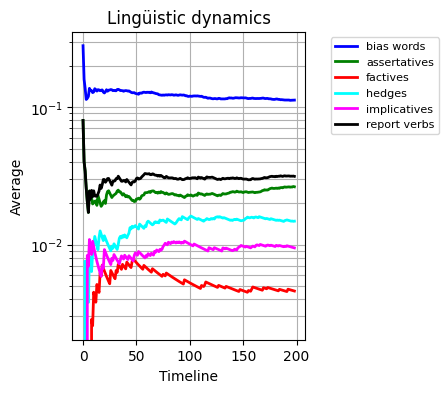

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

plt.style.use("default")

colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'black']

plt.figure(figsize=(3,4))
i = 0
for column in dfnew.columns:
    plt.plot(dfnew.index, dfnew[column], label=column, color = colors[i], linewidth=2)
    i = i + 1
    if i > 5: break

plt.xlabel("Timeline")
plt.ylabel("Average")
plt.yscale('log')

plt.title("Lingüistic dynamics")
plt.legend(loc='upper right', bbox_to_anchor=(1.6, 1), fontsize=8)
plt.grid(True, which="both")

plt.show()

Evolução da média acumulada das palavras de opinião positivas e negativas ao longo da linha do tempo das mensagens
*   Desvio na orientação de sentimento é representado pela inversão da prevalência de P ou N ao longo do gráfico (linhas se cruzam)

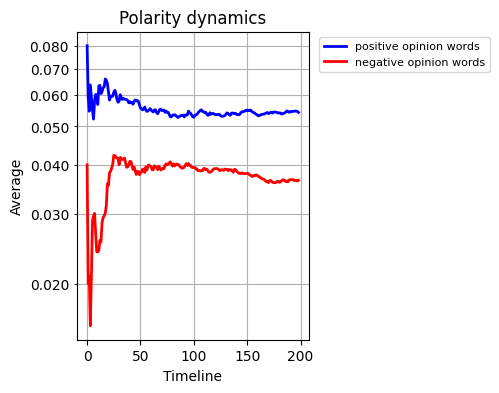

In [ ]:
colors = ['blue', 'red']

plt.figure(figsize=(3,4))

plt.plot(dfnew.index, dfnew['positive opinion words'], label='positive opinion words', color = colors[0], linewidth=2)
plt.plot(dfnew.index, dfnew['negative opinion words'], label='negative opinion words', color = colors[1], linewidth=2)

plt.xlabel("Timeline")
plt.ylabel("Average")
plt.yscale('log')

plt.gca().yaxis.set_major_formatter(ScalarFormatter())
plt.gca().yaxis.set_minor_formatter(ScalarFormatter())
plt.ticklabel_format(axis='y', style='plain')


plt.title("Polarity dynamics")
plt.legend(loc='upper right', bbox_to_anchor=(1.8, 1), fontsize=8)
plt.grid(True, which="both")

plt.show()

Distribuição da polaridade das mensagens estimada por densidade de kernel (KDE).

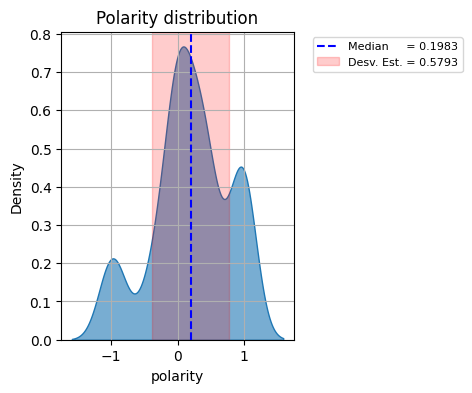

In [ ]:
import seaborn as sns

plt.figure(figsize=(3,4))
median = np.median(df['polarity'])
dv = df['polarity'].std()
sns.kdeplot(df['polarity'], fill=True, alpha=0.6, common_norm = True)
plt.grid(True)
plt.axvline(median, color='b', linestyle='--', label=f'Median     = {median:.4f}')
plt.axvspan(median - dv, median + dv, color='red', alpha=0.2, label=f'Desv. Est. = {dv:.4f}')
plt.title("Polarity distribution")
plt.legend(loc='upper right', bbox_to_anchor=(1.75, 1), fontsize=8)
plt.show()

In [ ]:
print(f"{median:.4f}",f"{dv:.4f}")

0.1983 0.5793
